# 🛠️ Data Processing Pipeline

This notebook executes all data processing pipelines step-by-step for the 3 modules. It handles the following:
1. **Data Loading**: Natively loads the raw `.csv` datasets
2. **Exploratory Checks**: Validates feature integrity and baseline target distributions
3. **Data Cleaning**: Drops invalid IDs and corrects types
4. **Feature Engineering**: Compresses seasonal timeseries Data and handles missing variables
5. **Formatting**: Evaluates dimensionality reduction (PCA) and handles standard scaling
6. **Export**: Saves the resulting engineered DataFrame outputs directly to `data/processed/` and `models/`

In [23]:
import sys
from pathlib import Path

# Ensure project root is in path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.config import (
    RAW_FILES,
    PROCESSED_FILES,
    MODEL_DIR,
    RANDOM_SEED,
    # ESA Module 1
    ESA_DROP_COLS, 
    ESA_TARGET_COL, 
    PCA_VARIANCE_THRESHOLD, 
    ESA_SEASONAL_BAND_PREFIXES, 
    ESA_SEASON_SUFFIXES,
    # Rural Module 2
    RURAL_TARGET_COL, RURAL_RISK_COL, RURAL_N_CLASSES, RURAL_CLASS_LABELS, RURAL_CAT_COLS,
    # SRDB Module 3
    SRDB_KEY_COLS
)

sns.set_theme(style="whitegrid")

In [24]:
def analyze_dataset(df, dataset_name):
    """Runs standard exploratory data analysis checks on a given DataFrame."""
    print(f"\n{'-'*50}")
    print(f"DATASET: {dataset_name}")
    print(f"{'-'*50}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"Total Missing Values: {null_count}")
        print("\nTop 5 Columns with Missing Data:")
        nulls = df.isnull().sum()
        print(nulls[nulls > 0].sort_values(ascending=False).head())
    else:
        print("No missing values detected.")
    print(f"{'-'*50}\n")

---
## 🌍 1. Module 1: ESA Remote Sensing (SOC Regression)
Given the enormous size of the ESA dataset (220+ target seasonal columns), this pipeline engineers grouped band statistics (`mean` and `std`) to compress sequential months, executes a `PCA` retention of 95% variance across all components, and separates out the target column (`logoc_d.f`).

In [25]:
# Load raw datasets
df_train_esa = pd.read_csv(RAW_FILES['esa_train'])
df_test_esa = pd.read_csv(RAW_FILES['esa_test'])

print(f"Raw Train Shape: {df_train_esa.shape}")
print(f"Raw Test Shape:  {df_test_esa.shape}")

Raw Train Shape: (23898, 227)
Raw Test Shape:  (7138, 226)



--------------------------------------------------
DATASET: ESA Satellite Training (RAW)
--------------------------------------------------
Shape: 23898 rows, 227 columns
No missing values detected.
--------------------------------------------------



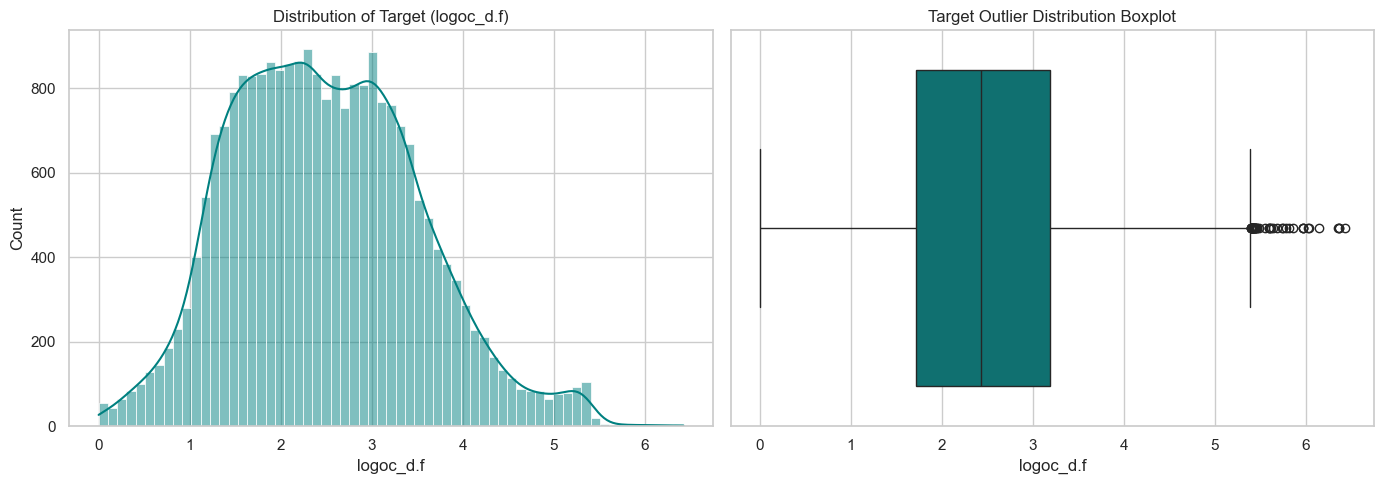

Calculating top feature correlations with target...


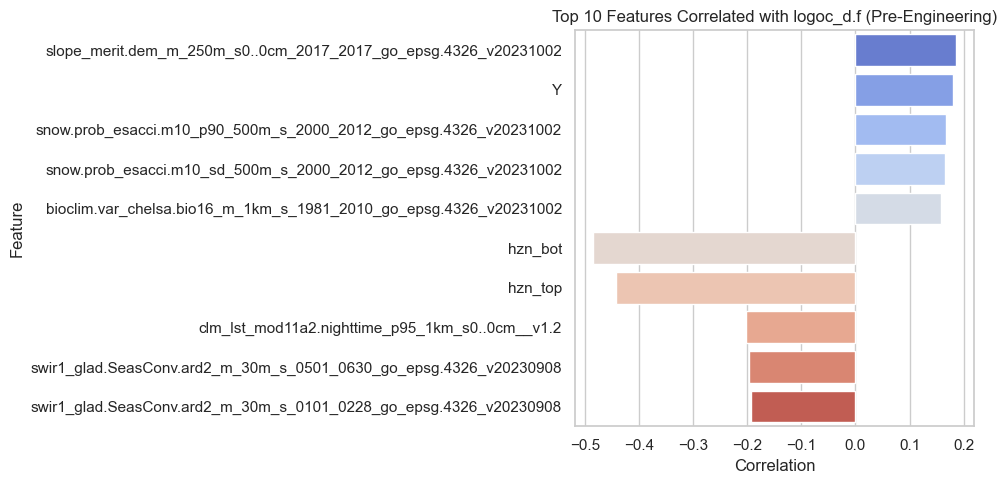

In [ ]:
# 🔍 EDA STEP 1: Baseline Integrity Check
analyze_dataset(df_train_esa, "ESA Satellite Training (RAW)")

# 📊 EDA STEP 2: Target Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the distribution of the target variable to see if it is skewed
sns.histplot(df_train_esa[ESA_TARGET_COL], kde=True, color='teal', ax=axes[0])
axes[0].set_title(f'Distribution of Target ({ESA_TARGET_COL})')
axes[0].set_xlabel('logoc_d.f')

# Plot a boxplot to review any extreme target outliers 
sns.boxplot(x=df_train_esa[ESA_TARGET_COL], color='teal', ax=axes[1])
axes[1].set_title('Target Outlier Distribution Boxplot')
axes[1].set_xlabel('logoc_d.f')
plt.tight_layout()
plt.show()

# 📈 EDA STEP 3: Initial Correlation Overview
print("Calculating top feature correlations with target...")

# Identify the strongest linear relationships against the target SOC 
corrs = df_train_esa.corr(numeric_only=True)[ESA_TARGET_COL].drop(ESA_TARGET_COL)
top_features = pd.concat([corrs.nlargest(5), corrs.nsmallest(5)]).reset_index()
top_features.columns = ['Feature', 'Correlation']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_features, x='Correlation', y='Feature', hue='Feature', dodge=False, palette='coolwarm', legend=False)
plt.title(f'Top 10 Features Correlated with {ESA_TARGET_COL} (Pre-Engineering)')
plt.tight_layout()
plt.show()

In [ ]:
# 🧹 1. Clean IDs and Invalid Non-Predictive Columns
drop_cols_train = [c for c in ESA_DROP_COLS if c in df_train_esa.columns]
drop_cols_test  = [c for c in ESA_DROP_COLS if c in df_test_esa.columns]

df_train_esa.drop(columns=drop_cols_train, inplace=True)
df_test_esa.drop(columns=drop_cols_test, inplace=True)

# ✨ 2. Engineer Soil Depth from Horizon levels
df_train_esa['soil_depth'] = df_train_esa['hzn_bot'] - df_train_esa['hzn_top']
df_test_esa['soil_depth']  = df_test_esa['hzn_bot']  - df_test_esa['hzn_top']

# 📉 3. Compress Sequential Time-Series Groups
def extract_seasonal_bands(df):
    """
    Finds all associated months for a seasonal band and engineers
    the total mean/std instead to reduce total columns exponentially.
    """
    cols_to_drop = []
    for prefix in ESA_SEASONAL_BAND_PREFIXES:
        band_cols = [c for c in df.columns if c.startswith(f"{prefix}_") and any(suffix in c for suffix in ESA_SEASON_SUFFIXES)]
        
        # If columns exist for this band, compress it
        if band_cols:
            df[f"{prefix}_mean"] = df[band_cols].mean(axis=1)
            df[f"{prefix}_std"] = df[band_cols].std(axis=1)
            cols_to_drop.extend(band_cols)
    
    # Drop all the raw repetitive month columns
    df.drop(columns=cols_to_drop, inplace=True)
    return df

df_train_esa = extract_seasonal_bands(df_train_esa)
df_test_esa  = extract_seasonal_bands(df_test_esa)

print(f"Post-Engineering Train Shape: {df_train_esa.shape}")
print(f"Post-Engineering Test Shape:  {df_test_esa.shape}")

Post-Engineering Train Shape: (23898, 141)
Post-Engineering Test Shape:  (7138, 140)


PCA reduced 140 features down to 60 principal components.
Total Variance Retained: 95.09%


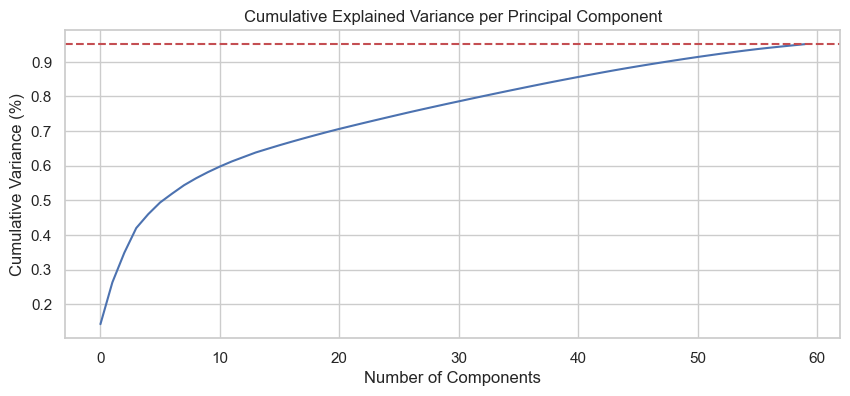

In [ ]:
# ✂️ 4. Split Target & Auto-Scale Features (Fit to Training data only)
y_train_esa = df_train_esa.pop(ESA_TARGET_COL).values
feature_cols_esa = df_train_esa.columns.tolist()

scaler_esa = StandardScaler()
X_train_scaled = scaler_esa.fit_transform(df_train_esa)

# Scale Test Data using the Training Distribution context to prevent data leakage
X_test_scaled  = scaler_esa.transform(df_test_esa[feature_cols_esa])

# 📉 5. Execute Principal Component Analysis (PCA) against scaled features
pca_esa = PCA(n_components=PCA_VARIANCE_THRESHOLD, random_state=RANDOM_SEED)
X_train_pca = pca_esa.fit_transform(X_train_scaled)
X_test_pca  = pca_esa.transform(X_test_scaled)

# Retrieve calculated variables of retained components
n_components = pca_esa.n_components_
variance_sum = float(np.sum(pca_esa.explained_variance_ratio_))

print(f"PCA reduced {len(feature_cols_esa)} features down to {n_components} principal components.")
print(f"Total Variance Retained: {variance_sum:.2%}")

# 📊 Plot PCA Explained Variance
plt.figure(figsize=(10,4))
plt.plot(np.cumsum(pca_esa.explained_variance_ratio_))
plt.axhline(y=PCA_VARIANCE_THRESHOLD, color='r', linestyle='--')
plt.title('Cumulative Explained Variance per Principal Component')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.show()

In [ ]:
# 💾 6. Export PCA-Transformed CSVs and Artifacts
# Reform numerical columns based on retained PC amount
pc_cols = [f"PC_{i+1}" for i in range(n_components)]
train_out_esa = pd.DataFrame(X_train_pca, columns=pc_cols)
train_out_esa[ESA_TARGET_COL] = y_train_esa

test_out_esa = pd.DataFrame(X_test_pca, columns=pc_cols)

# Dump transformed structures into data/processed/
train_out_esa.to_csv(PROCESSED_FILES['esa_train'], index=False)
test_out_esa.to_csv(PROCESSED_FILES['esa_test'], index=False)

# Dump transformer states into models/
joblib.dump(scaler_esa, MODEL_DIR / 'esa_scaler.pkl')
joblib.dump(pca_esa, MODEL_DIR / 'esa_pca.pkl')

print(f"Saved Processed Train:  {PROCESSED_FILES['esa_train'].name} (Shape: {train_out_esa.shape})")
print(f"Saved Processed Test:   {PROCESSED_FILES['esa_test'].name} (Shape: {test_out_esa.shape})")
print("Saved Transformers to models/esa_scaler.pkl, models/esa_pca.pkl")

Saved Processed Train:  esa_train_processed.csv (Shape: (23898, 61))
Saved Processed Test:   esa_test_processed.csv (Shape: (7138, 60))
Saved Transformers to models/esa_scaler.pkl, models/esa_pca.pkl


---
## 🌱 2. Module 2: Rural Carbon Context (Risk Classification)
Reads agricultural metadata, aggregates the raw carbon metric output (`Carbon_Emission_tCO2`) into 3 categorical quantile bins representing **Low / Medium / High Risk**, engineers 2 relational parameters, executes one-hot encoding on categorical strings, scales integers, and outputs the matrix formatted for simple Multi-Class evaluation.

In [30]:
df_rural = pd.read_csv(RAW_FILES['rural_carbon'])
print(f"Raw Rural Matrix Shape: {df_rural.shape}")
df_rural.head(3)

Raw Rural Matrix Shape: (3000, 13)


,Region,Month,Fertilizer_Usage_kg,Crop_Type,Crop_Area_ha,Livestock_Cows,Livestock_Pigs,Household_Energy_kWh,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,Year
0,R0103,4,106.5,Maize,37.3,0,130,296.6,0.58,23.6,70.7,5.91,2024
1,R0271,11,100.9,Wheat,47.4,95,196,408.8,0.50,24.9,275.5,21.63,2021
2,R0107,7,59.4,Maize,28.7,83,120,479.3,0.97,21.8,35.7,9.24,2022



--------------------------------------------------
DATASET: Rural Carbon Metrics (RAW)
--------------------------------------------------
Shape: 3000 rows, 316 columns
No missing values detected.
--------------------------------------------------



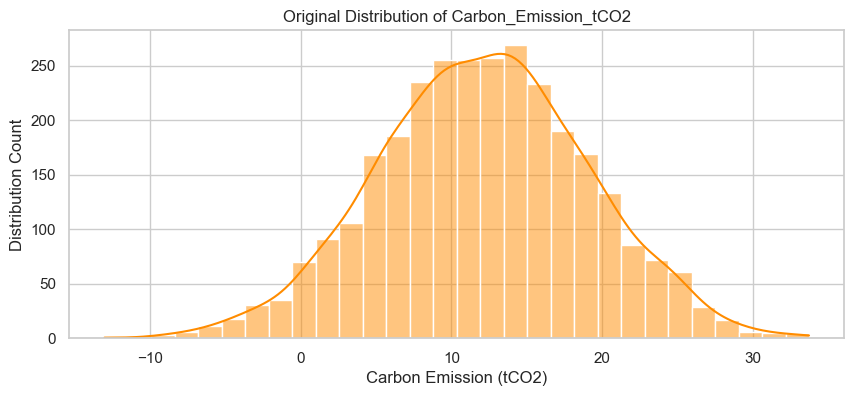

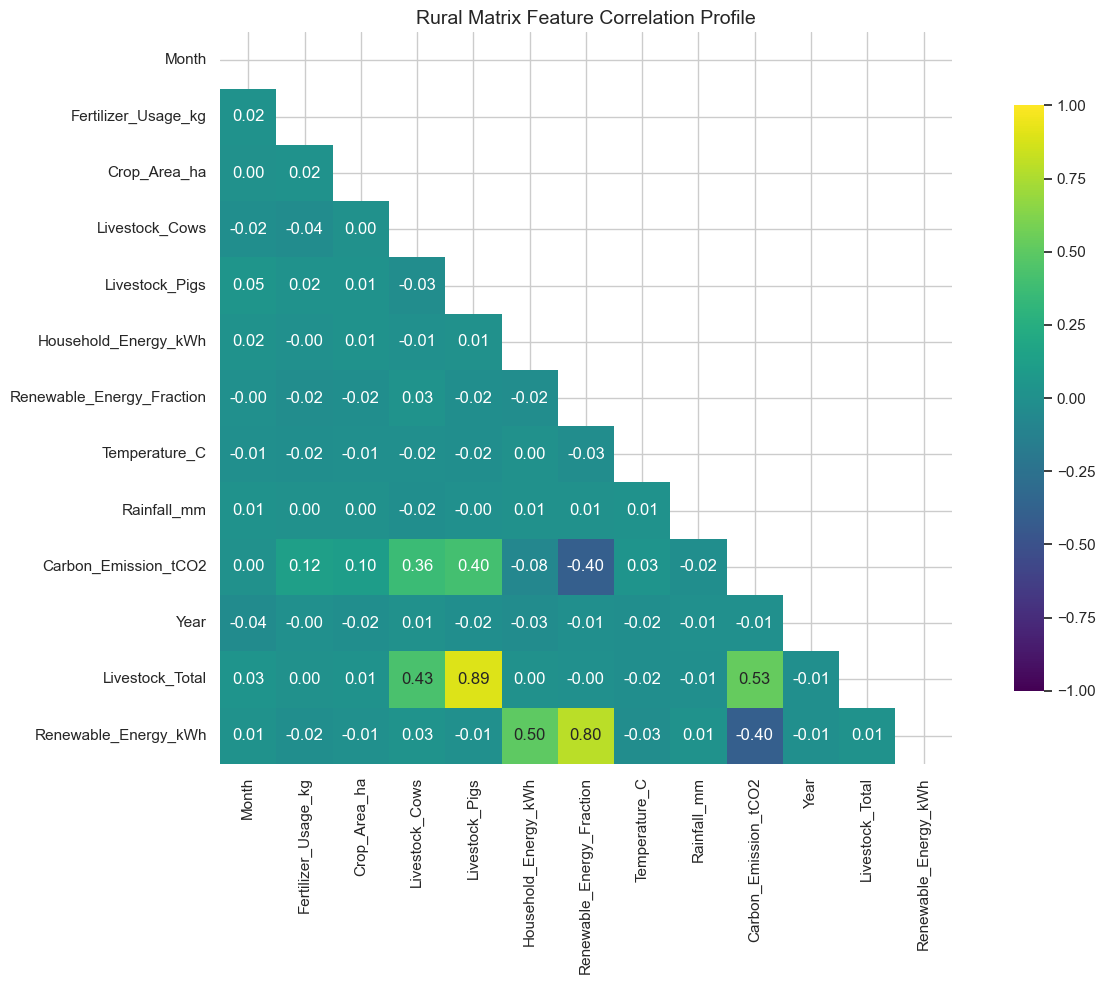

In [ ]:
# 🔍 EDA STEP 1: Rural Baseline Integrity
analyze_dataset(df_rural, "Rural Carbon Metrics (RAW)")

# 📊 EDA STEP 2: Baseline Target Validation
plt.figure(figsize=(10, 4))
sns.histplot(df_rural[RURAL_TARGET_COL], kde=True, color='darkorange', bins=30)
plt.title(f'Original Distribution of {RURAL_TARGET_COL}')
plt.xlabel('Carbon Emission (tCO2)')
plt.ylabel('Distribution Count')
plt.show()

# 📈 EDA STEP 3: Initial Multicollinearity Sub-Check before Engineering
rural_numeric = df_rural.select_dtypes(include=[np.number])
if len(rural_numeric.columns) > 1:
    plt.figure(figsize=(14, 10))
    corr_matrix = rural_numeric.corr()
    
    # Hide the symmetrical top-right half of the matrix to improve readability
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='viridis', 
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
    plt.title('Rural Matrix Feature Correlation Profile', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# ✨ 1. Bin Integer Target functionally into Low / Medium / High Quantiles
df_rural[RURAL_RISK_COL], bins_rural = pd.qcut(
    df_rural[RURAL_TARGET_COL],
    q=RURAL_N_CLASSES,
    labels=RURAL_CLASS_LABELS,
    retbins=True
)
print(f"Quantile bin thresholds mathematically map onto raw emissions as:\n     {list(np.round(bins_rural, 2))}")
print(f"\nNew Target Class Counts:\n{df_rural[RURAL_RISK_COL].value_counts()}")

Quantile bin thresholds mapping onto target:
     [np.float64(-13.02), np.float64(9.07), np.float64(15.06), np.float64(33.73)]

Class Counts:
Emission_Risk
Low       1002
High      1000
Medium     998
Name: count, dtype: int64


In [ ]:
# ✨ 2. Engineer Secondary Relational Parameters
if "Livestock_Cows" in df_rural.columns and "Livestock_Pigs" in df_rural.columns:
    df_rural["Livestock_Total"] = df_rural["Livestock_Cows"] + df_rural["Livestock_Pigs"]
if "Household_Energy_kWh" in df_rural.columns and "Renewable_Energy_Fraction" in df_rural.columns:
    df_rural["Renewable_Energy_kWh"] = df_rural["Household_Energy_kWh"] * df_rural["Renewable_Energy_Fraction"]

# ✂️ 3. One-hot Encoding for Category Variables
cats_present = [c for c in RURAL_CAT_COLS if c in df_rural.columns]
if cats_present:
    # Drops raw category cols and converts inner names to `col_val` format
    df_rural = pd.get_dummies(df_rural, columns=cats_present, drop_first=True)

# 📉 4. Standard Scaling Continuous Metrics
scaler_rural = StandardScaler()
numeric_cols_rural = df_rural.select_dtypes(include=[np.number]).columns.tolist()

# Ensure we don't accidentally scale the raw Target we just created thresholds for!
if RURAL_TARGET_COL in numeric_cols_rural:
    numeric_cols_rural.remove(RURAL_TARGET_COL)

df_rural[numeric_cols_rural] = scaler_rural.fit_transform(df_rural[numeric_cols_rural])

# Display engineered output shape overview
print(f"Post-Engineering Matrix Shape: {df_rural.shape}")
df_rural.head(3)

Post-Engineering Rural Matrix Shape: (3000, 316)


,Month,Fertilizer_Usage_kg,Crop_Area_ha,Livestock_Cows,Livestock_Pigs,Household_Energy_kWh,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,...,Region_R0294,Region_R0295,Region_R0296,Region_R0297,Region_R0298,Region_R0299,Region_R0300,Crop_Type_Maize,Crop_Type_Rice,Crop_Type_Wheat
0,-0.757329,-0.407911,0.739476,-1.703205,0.516532,-0.085013,0.257045,0.381142,-1.095227,5.91,...,False,False,False,False,False,False,False,True,False,False
1,1.276939,-0.537377,1.517671,1.594777,1.660017,0.898596,-0.017246,0.532377,1.458223,21.63,...,False,False,False,False,False,False,False,False,False,True
2,0.114500,-1.496811,0.076854,1.178190,0.343277,1.516639,1.594214,0.171740,-1.531608,9.24,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# 💾 5. Target Export Artifacts
df_rural.to_csv(PROCESSED_FILES['rural_carbon'], index=False)
joblib.dump(scaler_rural, MODEL_DIR / 'rural_scaler.pkl')

print(f"Saved Processed Rural:    {PROCESSED_FILES['rural_carbon'].name}")
print(f"Saved Transformer Scaler: models/rural_scaler.pkl")

Saved Processed Rural:    rural_carbon_processed.csv
Saved Transformer Scaler: models/rural_scaler.pkl


---
## 🕰️ 3. Module 3: SRDB Temporal Matrix (Respiration Rates)
Automatically drops missing measurement records devoid of `Rs_annual` benchmarking, handles temporal parsing into categorical Decades, calculates ratios between seasons vs raw sums, and executes climate imputation natively tracking regional ecosystem baselines.

In [35]:
df_srdb = pd.read_csv(RAW_FILES['srdb_data'], low_memory=False, encoding='latin1')
print(f"Raw SRDB Matrix Shape: {df_srdb.shape}")

Raw SRDB Matrix Shape: (10366, 85)



--------------------------------------------------
DATASET: SRDB Temporal Matrix (RAW)
--------------------------------------------------
Shape: 10366 rows, 85 columns
Total Missing Values: 543349

Top 5 Columns with Missing Data:
Duplicate_record    10278
Rs_autumn           10262
Rs_spring           10260
Ndep                10236
Rootlitter_flux     10221
dtype: int64
--------------------------------------------------

Missing Rs_annual records (CRITICAL before filter): 4625


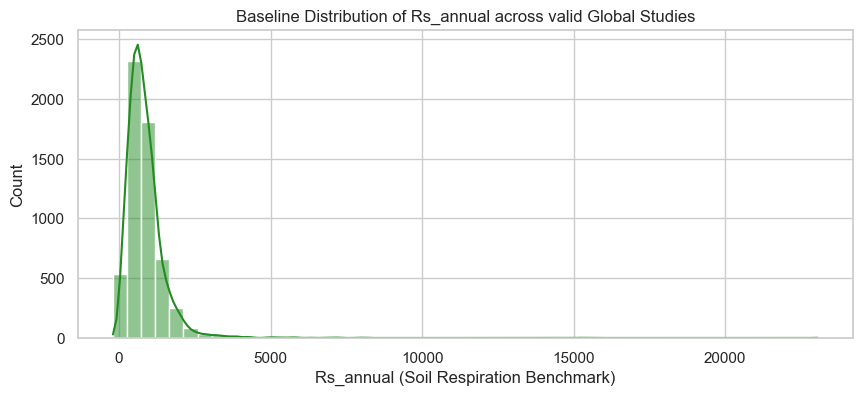

In [ ]:
# 🔍 EDA STEP 1: Global Benchmark Integrity
analyze_dataset(df_srdb, "SRDB Temporal Matrix (RAW)")

# 📊 EDA STEP 2: Vital Feature Null Output Alert
print(f"Missing Rs_annual records (CRITICAL before filter): {df_srdb['Rs_annual'].isna().sum()}")

# 📈 EDA STEP 3: Evaluate Benchmark Target Distributions
plt.figure(figsize=(10, 4))
sns.histplot(df_srdb['Rs_annual'].dropna(), bins=50, color='forestgreen', kde=True)
plt.title('Baseline Distribution of Rs_annual across valid Global Studies')
plt.xlabel('Rs_annual (Soil Respiration Benchmark)')
plt.show()

In [ ]:
# 🧹 1. Filter out excessive tracking variables not mapped in config
available_srdb_cols = [c for c in SRDB_KEY_COLS if c in df_srdb.columns]
df_srdb = df_srdb[available_srdb_cols].copy()

# ✂️ 2. Restrict to valid Geographical and Temporal benchmarks natively tracking Rs_annual
df_srdb = df_srdb[df_srdb["Rs_annual"].notna() & (df_srdb["Rs_annual"] > 0)]
df_srdb = df_srdb[df_srdb["Study_midyear"].notna()]
df_srdb = df_srdb[df_srdb["Latitude"].notna() & df_srdb["Longitude"].notna()]
print(f"Remaining shape after dropping sparse rows: {df_srdb.shape}")

# ✨ 3. Compress Temporal Measurements
df_srdb["Decade"] = (np.floor(df_srdb["Study_midyear"] / 10) * 10).astype(int)

# 📉 4. Engineer Ratio Values instead of raw seasonal summations
seasonal_cols = ["Rs_spring", "Rs_summer", "Rs_autumn", "Rs_winter"]
for col in seasonal_cols:
    if col in df_srdb.columns:
        ratio_col = col.replace("Rs_", "") + "_ratio"
        df_srdb[ratio_col] = df_srdb[col] / df_srdb["Rs_annual"]
        
# 🔄 5. Impute Climate Geography parameters using median fallback from same Biomes
for col in ["MAT", "MAP"]:
    if col in df_srdb.columns and df_srdb[col].isna().any():
        n_missing = df_srdb[col].isna().sum()
        
        # Attempt to map from same Biome environment
        biome_medians = df_srdb.groupby("Biome")[col].transform("median")
        df_srdb[col] = df_srdb[col].fillna(biome_medians)
        
        # If a Biome category itself falls through completely natively fall back global
        df_srdb[col] = df_srdb[col].fillna(df_srdb[col].median())
        print(f"Imputed {n_missing} ({col}) records based on underlying regional ecosystem trends.")

df_srdb.head()

After dropping heavily compromised sparse rows: (5551, 14)
Imputed 1300 (MAT) records based on underlying regional ecosystem trends.
Imputed 994 (MAP) records based on underlying regional ecosystem trends.


,Record_number,Study_midyear,Latitude,Longitude,Biome,Ecosystem_type,MAT,MAP,Rs_annual,Rs_spring,Rs_summer,Rs_autumn,Rs_winter,Rs_growingseason,Decade,spring_ratio,summer_ratio,autumn_ratio,winter_ratio
0,1.0,2001.5,56.63,-99.94,Boreal,Forest,0.8,450.0,255.0,NaN,NaN,NaN,NaN,1.30,2000,NaN,NaN,NaN,NaN
1,2.0,2001.5,56.46,-99.97,Boreal,Forest,0.8,450.0,85.0,NaN,NaN,NaN,NaN,0.60,2000,NaN,NaN,NaN,NaN
2,3.0,2001.5,55.91,-98.98,Boreal,Forest,0.8,450.0,425.0,NaN,NaN,NaN,NaN,1.98,2000,NaN,NaN,NaN,NaN
3,4.0,2001.5,55.86,-98.48,Boreal,Forest,0.8,450.0,551.0,NaN,NaN,NaN,NaN,2.75,2000,NaN,NaN,NaN,NaN
4,5.0,2001.5,55.92,-98.39,Boreal,Forest,0.8,450.0,484.0,NaN,NaN,NaN,NaN,2.20,2000,NaN,NaN,NaN,NaN


In [ ]:
# 💾 6. Export Benchmark Matrices
df_srdb.to_csv(PROCESSED_FILES['srdb_temporal'], index=False)
print(f"Saved Processed SRDB: {PROCESSED_FILES['srdb_temporal'].name} | Final Shape: {df_srdb.shape}")

Saved Processed SRDB: srdb_temporal_processed.csv | Final Shape: (5551, 19)
